# Policy Optimization
This notebook demonstrates how metaheuristic search can be used to optimize the holding policies in effect along a fixed-line transit route. We compare with two baselines: Liu et al. [1] and Zhao et al. [2], as well as a completely uncontrolled route.

[1] S. Liu, X. Luo, and P. J. Jin, "Improving bus operations through integrated dynamic holding control and schedule optimization," *Journal of Advanced Trasportation*, vol. 2018, no. 1, p. 9714046, 2018.

[2] L. Zhao, S. I. Chien, L. N. Spasovic, and X. Liu, "Modeling and optimizing urban bus transit considering headway variation for cost and service reliability analysis," *Transporation Planning and Technology*, vol. 41, no. 7, pp. 706-723. 2018.

In [82]:
from collections import defaultdict
from copy import deepcopy
from dataclasses import dataclass
from math import exp, log, sqrt
from os import path
from random import choice, random, seed
from time import time

from pandas import read_csv
from plotly import graph_objects
from plotly import express
from scipy.special import erfinv

from analysis.policies import *
from analysis.routes import *
from analysis.prob_analysis import *
from analysis.wc_analysis import *

import numpy
import pygad

## Plotting Helpers

In [83]:
@dataclass
class GtfsStopConfig(StopConfig):
    """Configuration information required to construct a ```Stop``` with additional information appearing in a GTFS.

    :param stop_id: The stop_id as per the GTFS.
    :param arrival_rate: The number of passengers per minute arriving at stop.
    :param mean_dwell: The mean dwell time at the stop.
    :param mean_travel: The mean travel time leaving the stop.
    :param travel_var: The variance in travel time leaving the stop.
    """ 
    stop_id: str
    arrival_rate: float
    mean_dwell: float
    mean_travel: float
    travel_var: float

In [84]:
@dataclass
class RouteConfig(object):
    """Configuration information that defines a route variant under test.
    
    :param name: Name used for identification.
    :param route: List of stops.
    :param start_times: List of times when vehicles start serving the route.
    """ 
    name: str
    route: list[Stop]
    start_times: list[float]

In [85]:
@dataclass
class HeadwayResults(object):
    """Headway experiment results.
    
    :param upper_bound: List of maximum possible headway at each stop.
    :param lower_bound: List of minimum possible headway at each stop.
    :param observed: List of headway times observed during simulation at each stop.
    """ 
    upper_bound: list[float]
    lower_bound: list[float]
    observed: list[list[float]]

In [86]:
@dataclass
class RouteResults(object):
    """Results from an experiment on one route variant.
    
    :param name: Name used for identification.
    :param route: The route under consideration.
    :param headway: Simulated and analytical headway results for the route.
    :param travel_time: Measured travel times between all pairs of stops.
    """ 
    name: str
    route: list[Stop]
    headway: HeadwayResults
    travel_time: list[list[list[float]]]

## Load a Route from a GTFS
Methods to create a route based on a GTFS and historic data.

In [87]:
def get_quantile_log_normal(mu: float, sigma: float, q: float) -> float:
    """Get a quantile's upper boundary (x | p(X < x) = q) for a log-normal distribution parameterized by mu and sigma.

    :param mu: The distribution's logarithm of location.
    :param sigma: The distribution's logarithm of scale.
    :return: The quantile's upper bound.
    """
    return exp(mu + sqrt(2 * sigma ** 2) * erfinv(2 * q - 1))

In [88]:
def get_log_normal_mixture(mu: list[float], sigma: list[float], weights: list[float] | None = None) -> tuple[float]:
    """Get the parameters of a log normal mixture approximated by log normal distribution.
    
    :param mu: List of logarithms of location for every log-normal distribution in the mixture.
    :param sigma: List of logarithms of scale for every log-normal distribution in the mixture.
    :param weight: List of weights for each log-normal distribution in the mixture.
    """
    assert len(mu) == len(sigma)
    if weights is None:
        w = [1 / len(mu) for _ in range(len(mu))]
    else:
        assert len(weights) == len(mu)
        w = weights

    # Calculate moments
    m1 = 0
    m2 = 0
    for i in range(len(mu)):
        m1 += w[i] * exp(mu[i] + (sigma[i] ** 2) / 2)
        m2 += (w[i] ** 2) * exp(2 * mu[i] + 2 * sigma[i] ** 2)
    temp = 0
    for i in range(len(sigma)):
        for j in range(i+1,len(sigma)):
            temp += (w[i] * w[j]) * exp(mu[i] + mu[j] + 0.5 * (sigma[i] ** 2 + sigma[j] ** 2))
    m2 = m2 + 2 * temp

    # Calculate new parameters
    sigma = sqrt(log(m2/(m1 ** 2)))
    mu = log(m1) - (sigma ** 2) / 2
    return mu, sigma

In [89]:
def load_route_from_gtfs(route_id: int, service_day: str) -> list[GtfsStopConfig]:
    """Create a route template from a GTFS.

    .. note ::
        This function does not load the stop schedules from the GTFS.  The assumption is that scheduled headway and number of vehicles
        are variables in the fixed-line route optimization problem.

    :param route_id: The route id in the GTFS.
    :param service_day: The service day in the GTFS the route template will be based on.
    :return: List of stop configurations in order of service.
    :raises ValueError:
    """
    calendar = read_csv(path.join('gtfs', 'calendar.txt'))
    trips = read_csv(path.join('gtfs', 'trips.txt'))
    stops = read_csv(path.join('gtfs', 'stops.txt'))
    stop_times = read_csv(path.join('gtfs', 'stop_times.txt'))

    # Get service_id for selected day
    active_service_ids = calendar[calendar[service_day] == 1].service_id
    if len(active_service_ids) == 0:
        raise ValueError(f'No service on {service_day} in GTFS!')
    elif len(active_service_ids) > 1:
        raise ValueError(f'Multiple services on {service_day} in GTFS: multiple services are currently not supported!')
    service_id = active_service_ids.iloc[0]

    # Get the trips we care about
    trips = trips[(trips.service_id == service_id) & (trips.route_id == route_id)]

    # Map patterns (unique sequences of stops) to trips
    patterns_by_direction_id = defaultdict(set)
    trips_by_pattern = defaultdict(set)
    for block_id in [int(b) for b in trips.block_id.unique()]:
        for trip_id in [int(t) for t in trips[trips.block_id == block_id].trip_id.unique()]:
            pattern = tuple(stop_times[stop_times.trip_id == trip_id].sort_values(by='stop_sequence').stop_id)
            patterns_by_direction_id[trips[trips.trip_id == trip_id].direction_id.iloc[0].item()].add(pattern)
            trips_by_pattern[pattern].add(trip_id)

    # Select the most common pattern for each direction ID (we're ignoring weird, one-off patterns)
    selected_pattern_by_direction_id = {}
    for direction_id, patterns in patterns_by_direction_id.items():
        selected_pattern = max(patterns, key=lambda pattern: len(trips_by_pattern[pattern]))
        selected_pattern_by_direction_id[direction_id] = selected_pattern

    # Map stop_id and direction_id to Stop objects
    # Note: we assume direction_id=1, is the starting leg of the route
    stop_info = []
    for direction_id in list(selected_pattern_by_direction_id.keys())[::-1]:
        # Last stop in pattern is duplicated, since it is the first stop in the next direction
        for stop_id in selected_pattern_by_direction_id[direction_id][:-1]:
            stop_info.append(GtfsStopConfig(
                tau=None,
                delta=None,
                policy=BolehPolicy,
                policy_args={},
                stop_id=stop_id,
                arrival_rate=None,
                mean_dwell=None,
                mean_travel=None,
                travel_var=None,
            ))

    return stop_info

In [90]:
def load_times(route: list[GtfsStopConfig], service_day: str, lower_quantile: float, upper_quantile: float) -> list[GtfsStopConfig]:
    """Load the travel and dwell times for a route defined in the GTFS.

    .. warning ::
        This function modifies the route argument in addition to returning a route.
    
    :param route: List of stop configuration in order of stops.
    :param service_day: The day of the weak whose data will be used to calculate the parameters.
    :param lower_quantile: The lower quantile of observed travel and dwell times to consider.
    :param upper_quantile: The uppler quantile of observed travel and dwell times to consider.
    :return: The route with updated travel and dwell time bounds.
    """
    travel_times = read_csv(path.join('data', 'travel_times.csv'))
    alight_rates = read_csv(path.join('data', 'alight_rates.csv'))
    demand_rates = read_csv(path.join('data', 'demand_rates.csv'))

    for stop in route:
        tt = travel_times[(travel_times.day_of_week == service_day) & (travel_times.from_stop_id == stop.stop_id)]
        tt_mu = list(tt.mean_log_travel_time_s)
        tt_sigma = list(tt.std_log_travel_time_s)
        mu, sigma = get_log_normal_mixture(tt_mu, tt_sigma)
        lower = get_quantile_log_normal(mu, sigma, lower_quantile) / 60
        upper = get_quantile_log_normal(mu, sigma, upper_quantile) / 60
        stop.tau = (lower, upper)
        stop.mean_travel = get_quantile_log_normal(mu, sigma, 0.5) / 60
        stop.travel_var = exp(sigma ** 2 - 1) * exp(2 * mu + sigma ** 2)

        ar = alight_rates[alight_rates.STOP_ID == stop.stop_id]
        ar = list(ar.ALIGHT_RATE)
        dr = demand_rates[demand_rates.STOP_ID == stop.stop_id]
        dr = list(dr.HOURLY_DEMAND)
        stop.arrival_rate = sum(dr) / (len(dr) * 60)

        weights = []
        for a, d in zip(ar, dr):
            weights.extend([10 / len(ar), 2 * a / len(ar), 3.5 * d / len(dr)])
        mu, sigma = get_log_normal_mixture([0 for _ in range(len(weights))], [0.1 for _ in range(len(weights))], weights)
        lower = get_quantile_log_normal(mu, sigma, lower_quantile) / 60
        upper = get_quantile_log_normal(mu, sigma, upper_quantile) / 60
        stop.delta = (lower, upper)
        stop.mean_dwell = get_quantile_log_normal(mu, sigma, 0.5) / 60

    return route

In [91]:
BASE_ROUTE = load_route_from_gtfs(route_id=55, service_day='monday')
BASE_ROUTE = load_times(BASE_ROUTE, service_day='Monday', lower_quantile=0.05, upper_quantile=0.95)

## Experiments

In [92]:
# The following are the only stops allowed to be considered for control during headway optimization:
CTRL_PTS = ['HICHICNN', 'MXIBELL', 'MXIGLENG', 'MXITHOMP', 'MCC4_13', 'MXOTHOMP', 'MXOGLENG', 'MXOBELL']


# The following are additional route parameters that form a set of optimization constraints on the optimization variables' domains:

# Number of buses
N_BUSES = 16

# Maximum holding time for the dynamic holding policy
MAX_HOLD = 60

# Minimum and maximum travel time along a route (excluding worst-case schedule holding with bunched buses)
MIN_TRAVEL = sum([min(*s.tau) + min(*s.delta) for s in BASE_ROUTE])
MAX_TRAVEL = sum([max(*s.tau) + max(*s.delta) for s in BASE_ROUTE]) + MAX_HOLD

# Minimum and maximum offset for for scheduled holds
MIN_CTRL = [0 for _ in CTRL_PTS]
MAX_CTRL = [0 for _ in CTRL_PTS]
finished = [False for _ in CTRL_PTS]
for stop in BASE_ROUTE:
    for idx, ctrl_pt in enumerate(CTRL_PTS):
        if not finished[idx]:
            MIN_CTRL[idx] += (min(*stop.tau) + min(*stop.delta))
            MAX_CTRL[idx] += (max(*stop.tau) + max(*stop.tau))
        if stop.stop_id == ctrl_pt:
            finished[idx] = True
            MAX_CTRL[idx] += MAX_HOLD


# GA Parameters
T_MAX = 60 * 24
POPULATION_SIZE = 20
MATING_PAIRS = 10
GENERATIONS = 20
MUTATION_PCNT = 10
STOP_CRITERIA = "saturate_5"

In [93]:
# Seed all the RNGs before starting experiments
seed(0)
numpy.random.seed(0)

### Liu et al.
Constructs a unique slack driven policy at each stop.

In [95]:
gene_space = []
for stop in BASE_ROUTE:
    gene_space.append({"low": 0.0, "high": 60.0})
for stop in BASE_ROUTE:
    gene_space.append({"low": 0.0, "high": 1.0})
for stop in CTRL_PTS:
    gene_space.append([0, 1])

def fitness_liu_et_al(ga: pygad.GA, solution: list, solution_idx: int) -> float:
    """Fitness function for Liu et al.'s optimization method.  All variable names are left as close to their corresponding mathematical
    symbols in the paper as possible.

    :param ga: The PyGad GA object.
    :param solution: The list of genes to be evaluated.
    :param solution_idx: The solution index in PyGad's GA.
    :return: The solution's fitness.
    """
    zeta_wait = 2.1
    L_min = 20

    var_eps = []
    var_AC = []
    eta = []
    d = []
    l = []
    f = []
    ctrl_idx = 0
    for idx, stop in enumerate(BASE_ROUTE):
        d.append(solution[idx])
        f.append(solution[len(BASE_ROUTE) + idx])
        if stop.stop_id in CTRL_PTS:
            eta.append(solution[len(BASE_ROUTE) * 2 + ctrl_idx])
            ctrl_idx += 1
        else:
            eta.append(0)
        var_AC.append((f[idx] ** 2) * var_eps[idx - 1] if idx > 0 else 0)
        var_eps.append(
            var_AC[idx] + stop.travel_var if eta[idx] == 1 or idx == 0 else (1 + 3.5 * stop.arrival_rate / 60) ** 2 * var_eps[idx - 1]
        )
        l.append([1 / len(BASE_ROUTE) for _ in range(len(BASE_ROUTE))])

    H = (
        sum([d[idx] + stop.mean_travel for idx, stop in enumerate(BASE_ROUTE[:-1])]) + L_min + 3 * sqrt(var_eps[-1])
    ) / (N_BUSES + sum([3.5 * stop.arrival_rate / 60 for stop in BASE_ROUTE[:-1]]))

    T_wait = []
    for idx, stop in enumerate(BASE_ROUTE):
        T_wait.append(
            ((H - d[idx]) / 2) * (1 + (var_AC[idx] + var_eps[idx]) / ((H - d[idx]) ** 2)) * ((H - d[idx]) / H)
        )
    
    T_wait = sum([stop.arrival_rate * T_wait[idx] for idx, stop in enumerate(BASE_ROUTE)]) / sum([stop.arrival_rate for stop in BASE_ROUTE])
    T_exwait = 0 # Assume 0 since passenger numbers are low
    T_inveh = (
        sum([
            sum([
                sum([
                    stop_i.arrival_rate * l[idx][jdx] * (3.5 * stop_k.arrival_rate / 60 * H + d[kdx] + stop_k.mean_travel) for kdx, stop_k in enumerate(BASE_ROUTE[idx:jdx + 1])
                ]) for jdx in range(idx,len(BASE_ROUTE))
            ]) for idx, stop_i in enumerate(BASE_ROUTE)
        ]) - sum([stop.arrival_rate * (3.5 * stop.arrival_rate / 60 * H + d[idx]) for idx, stop in enumerate(BASE_ROUTE[:-1])]) / 2
    ) / sum([stop.arrival_rate for stop in BASE_ROUTE])
    objective = zeta_wait * (T_wait + T_exwait) + T_inveh
    return -objective # Goal is to minimize objective

ga_liu_et_al = pygad.GA(
    num_generations=GENERATIONS,
    num_parents_mating=MATING_PAIRS,
    fitness_func=fitness_liu_et_al,
    sol_per_pop=POPULATION_SIZE,
    num_genes=len(gene_space),
    gene_space=gene_space,
    parent_selection_type='sss',
    keep_parents=1,
    crossover_type='single_point',
    mutation_type='random',
    mutation_percent_genes=MUTATION_PCNT,
    save_solutions=True,
    stop_criteria=STOP_CRITERIA,
)

start = time()
ga_liu_et_al.run()
liu_et_al_time = time() - start
liu_et_al_solution, liu_et_al_solution_fitness, liu_et_al_solution_idx = ga_liu_et_al.best_solution()
print(f'Total Optimization Time: {liu_et_al_time}')

/home/michael/git/bus-transit-headway-bounds/headway-analysis/lib/python3.12/site-packages/pygad/utils/validation.py:1208: UserWarning: Use the 'save_solutions' parameter with caution as it may cause memory overflow when either the number of generations, number of genes, or number of solutions in population is large.
  warnings.warn("Use the 'save_solutions' parameter with caution as it may cause memory overflow when either the number of generations, number of genes, or number of solutions in population is large.")


Total Optimization Time: 9.266502857208252


In [96]:
len(ga_liu_et_al.solutions)

420

In [97]:
# Generate a route with the winning solution for analysis
LIU_ROUTE = deepcopy(BASE_ROUTE)

L_min = 20
var_eps = []
var_AC = []
eta = []
d = []
l = []
f = []
ctrl_idx = 0
for idx, stop in enumerate(BASE_ROUTE):
    d.append(liu_solution[idx])
    f.append(liu_solution[len(BASE_ROUTE) + idx])
    if stop.stop_id in CTRL_PTS:
        eta.append(liu_solution[len(BASE_ROUTE) * 2 + ctrl_idx])
        ctrl_idx += 1
    else:
        eta.append(0)
    var_AC.append((f[idx] ** 2) * var_eps[idx - 1] if idx > 0 else 0)
    var_eps.append(var_AC[idx] + stop.travel_var if eta[idx] == 1 or idx == 0 else (1 + 3.5 * stop.arrival_rate / 60) ** 2 * var_eps[idx - 1])
    l_i = []
    for jdx in range(len(BASE_ROUTE)):
        l_i.append(1/len(BASE_ROUTE))
    l.append(l_i)
H = (sum([d[idx] + stop.mean_travel for idx, stop in enumerate(BASE_ROUTE[:-1])]) + L_min + 3 * sqrt(var_eps[-1])) / (N_BUSES + sum([3.5 * stop.arrival_rate / 60 for stop in BASE_ROUTE[:-1]]))

for stop_idx in range(len(LIU_ROUTE)):
    for idx, ctrl_pt in enumerate(CTRL_PTS):
        if LIU_ROUTE[stop_idx].stop_id == ctrl_pt:
            if liu_solution[2 * len(BASE_ROUTE) + CTRL_PTS.index(ctrl_pt)] == 1:
                LIU_ROUTE[stop_idx].policy = SlackDrivenPolicy
                LIU_ROUTE[stop_idx].policy_args = {
                    'headway': H,
                    'scheduled_slack': liu_solution[stop_idx],
                    'efficiency_coefficient': liu_solution[len(BASE_ROUTE) + stop_idx],
                    'beta': 3.5 * LIU_ROUTE[stop_idx].arrival_rate / 60
                }

liu_start_times = [i * H for i in range(N_BUSES)]
headway_ub, headway_lb = headway_bounds(route_factory(LIU_ROUTE), liu_start_times, T_MAX * 100)
liu_ub = []
liu_lb = []
for stop_idx in range(len(LIU_ROUTE)):
    for idx, ctrl_pt in enumerate(CTRL_PTS):
        if LIU_ROUTE[stop_idx].stop_id == ctrl_pt:
            liu_ub.append(headway_ub[stop_idx])
            liu_lb.append(headway_lb[stop_idx])
print(liu_ub)
print(liu_lb)

[np.float64(93.62679958043327), 0, 0, 0, 0, 0, np.float64(76.90602170239663), np.float64(49.696006254730946)]
[np.float64(114.9893152951463), 0, np.float64(118.6112829719694), np.float64(117.71330016309605), 0, 0, np.float64(113.26017050183236), np.float64(72.9699964011038)]


### Zhao et al.
We ignore their stop placement selection and focus on their schedule optimization given fixed stop locations.

In [98]:
gene_space = [
    {"low": N_BUSES / MAX_TRAVEL, "high": N_BUSES / MIN_TRAVEL}
]

def fitness_zhao_et_al(ga: pygad.GA, solution: list, solution_idx: int) -> float:
    """Fitness function for Zhao et al.'s optimization method.  We ignore any terms dependent on stop locations and optimize only for
    scheduled headway.  All variables names are left as close to their corresponding mathematical symbols in the paper as possible.

    :param ga: The PyGad GA object.
    :param solution: The list of genes to be evaluated.
    :param solution_idx: The solution index in PyGad's GA.
    :return: The solution's fitness.
    """
    zeta_wait = 2.1
    H = solution[0]
    rho = 3.5 / 60
    t_w = 0
    t_v = 0
    v = []
    b = []
    for idx, stop in enumerate(BASE_ROUTE):
        if idx == 0:
            b.append(0)
            v.append(0)
        else:
            b.append(stop.arrival_rate * H)
            v_tr = stop.travel_var
            l = stop.mean_travel
            v.append((1 + 4 * rho * b[idx - 1] ** 2 + 2 * rho * b[idx]) * v[idx - 1] + l * v_tr)
        t_w += b[idx] * (H / 2 + v[idx] / (2 * H))
    for idx, stop_i in enumerate(BASE_ROUTE):
        for jdx, stop_j in enumerate(BASE_ROUTE):
            if stop_i.stop_id == stop_j.stop_id:
                continue
            t_v += (b[idx] / len(BASE_ROUTE)) * (sum([s.mean_travel for s in BASE_ROUTE[idx:jdx]]) + sum([rho * b[kdx + idx] * (H ** 2 + (1 + 2 * rho * b[idx]) * v[idx]) for kdx, s in enumerate(BASE_ROUTE[idx:jdx])]))
    objective = zeta_wait * t_w + t_v
    return -objective

ga_zhao_et_al = pygad.GA(
    num_generations=GENERATIONS, # Remeber to increase
    num_parents_mating=MATING_PAIRS,
    fitness_func=fitness_zhao_et_al,
    sol_per_pop=POPULATION_SIZE,
    num_genes=len(gene_space),
    gene_space=gene_space,
    parent_selection_type='sss',
    keep_parents=1,
    crossover_type='single_point',
    mutation_type='random',
    mutation_percent_genes=MUTATION_PCNT,
    save_solutions=True,
    stop_criteria=STOP_CRITERIA,
)

start = time()
ga_zhao_et_al.run()
zhao_et_al_time = time() - start
zhao_et_al_solution, zhao_et_all_solution_fitness, zhao_et_all_solution_idx = ga_zhao_et_al.best_solution()
print(f'Total Optimization Time: {zhao_et_al_time}')

/home/michael/git/bus-transit-headway-bounds/headway-analysis/lib/python3.12/site-packages/pygad/utils/validation.py:690: UserWarning: The percentage of genes to mutate (mutation_percent_genes=10) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(f"The percentage of genes to mutate (mutation_percent_genes={mutation_percent_genes}) resulted in selecting ({mutation_num_genes}) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).\nIf you do not want to mutate any gene, please set mutation_type=None.")


Total Optimization Time: 4.114386558532715


In [99]:
len(ga_zhao_et_al.solutions)

120

In [100]:
H = zhao_solution[0]
L = 20
ZHAO_ROUTE = deepcopy(BASE_ROUTE)
ZHAO_ROUTE[0].policy = InfiniteSchedulePolicy
ZHAO_ROUTE[0].policy_args = {
    'time_delta': H,
    'offset': sum([s.mean_travel + s.mean_dwell for s in ZHAO_ROUTE]) + L,
}
zhao_start_times = [i * H for i in range(N_BUSES)]
headway_ub, headway_lb = headway_bounds(route_factory(ZHAO_ROUTE), zhao_start_times, T_MAX)
zhao_ub = []
zhao_lb = []
for stop_idx in range(len(ZHAO_ROUTE)):
    for idx, ctrl_pt in enumerate(CTRL_PTS):
        if ZHAO_ROUTE[stop_idx].stop_id == ctrl_pt:
            zhao_ub.append(headway_ub[stop_idx])
            zhao_lb.append(headway_lb[stop_idx])
print(zhao_ub)
print(zhao_lb)

[np.float64(127.88761334547146), np.float64(134.15036827145263), np.float64(134.37114617773122), np.float64(134.07799006250488), np.float64(132.61113390687257), np.float64(134.76039593519744), np.float64(134.73549036212648), np.float64(134.7421504922487)]
[0, 0, 0, 0, 0, 0, 0, 0]


### Ours
We optimize over three possible stop policies at each control point.

In [101]:
gene_space = [
    {"low": N_BUSES / MAX_TRAVEL, "high": N_BUSES / MIN_TRAVEL},
]
for ctrl_pt in CTRL_PTS:
    gene_space.extend([
        [0, 1, 2],
        {"low": 0.0, "high": 1.0},
        {"low": 0.0, "high": 1.0},
    ])

def fitness_ours(ga: pygad.GA, solution: list, solution_idx: int) -> float:
    """This is the fitness function for the genetic algorithm.

    The solution parameter indices represent the following:
    0: Number of buses
    1: Initial headway between buses at start of route
    2, 5, 8, 11, ... : The policy for the (n-2)/3rd control point:
        0 - No holding
        1 - Schedule based control
        2 - Headway based control
    3, 6, 9, 12, ... : The first policy parameter for the (n-3)/3rd control point:
        0 - Nothing
        1 - Time delta
        2 - Activation ratio
    4, 7, 10, 13, ... : The second policy parameter for the (n-4)/3rd control point:
        0 - Nothing
        1 - Scheduling offset
        2 - Maximum holding time
    
    :param solution: List parameters for the soluton under test.
    :param solution_idx: Solution index from PyGAD.
    :return: The solution fitness. 
    """
    mx_hold_time = 0
    solution = [None, *solution]
    start_times = [bus * solution[1] for bus in range(N_BUSES)]
    route = deepcopy(BASE_ROUTE)
    param_idx = 2
    for stop_idx in range(len(route)):
        for idx, ctrl_pt in enumerate(CTRL_PTS):
            if route[stop_idx].stop_id == ctrl_pt:
                policy = solution[param_idx]
                arg1 = solution[param_idx + 1]
                arg2 = solution[param_idx + 2]
                param_idx += 3
                if policy == 0:
                    pass
                elif policy == 1:
                    route[stop_idx].policy = InfiniteSchedulePolicy
                    route[stop_idx].policy_args = {
                        'time_delta': N_BUSES / MAX_TRAVEL * (1 - arg1) + arg1 * N_BUSES / MIN_TRAVEL,
                        'offset': MIN_CTRL[idx] * (1 - arg2) + arg2 * MAX_CTRL[idx],
                    }
                    mx_hold_time += (N_BUSES - 1) * N_BUSES / MAX_TRAVEL * (1 - arg1) + arg1 * N_BUSES / MIN_TRAVEL
                elif policy == 2:
                    route[stop_idx].policy = HeadwayDrivenPolicy
                    route[stop_idx].policy_args = {
                        'activation_ratio': arg1,
                        'max_holding': arg2 * MAX_HOLD,
                    }
                    mx_hold_time += arg2
    headway_ub, headway_lb = headway_bounds(route_factory(route), start_times, T_MAX)
    fitness = -max(headway_ub)
    return [fitness, -mx_hold_time]

ga_ours = pygad.GA(
    num_generations=GENERATIONS,
    num_parents_mating=MATING_PAIRS,
    fitness_func=fitness_ours,
    sol_per_pop=POPULATION_SIZE,
    num_genes=len(gene_space),
    gene_space=gene_space,
    parent_selection_type='nsga2',
    keep_parents=1,
    crossover_type='single_point',
    mutation_type='random',
    mutation_percent_genes=MUTATION_PCNT,
    save_solutions=True,
    stop_criteria=STOP_CRITERIA,
)

start = time()
ga_ours.run()
our_time = time() - start
our_solution, our_solution_fitness, our_solution_idx = ga.best_solution()
print(f'Total Optimization Time: {our_time}')

Total Optimization Time: 384.1633381843567


In [102]:
len(ga_ours.solutions)

340

In [103]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 16


fig = ga.plot_pareto_front_curve(
    xlabel="Max. Headway Variation",
    ylabel="Max. Unscheduled Holding Time",
)

raw_scores = numpy.array(ga.last_generation_fitness)
minimization_values = -raw_scores

is_pareto = numpy.ones(minimization_values.shape[0], dtype=bool)
for i, c in enumerate(minimization_values):
    if is_pareto[i]:
        is_pareto[is_pareto] = numpy.any(minimization_values[is_pareto] < c, axis=1) | numpy.all(minimization_values[is_pareto] == c, axis=1)
        is_pareto[i] = True

pareto_front = minimization_values[is_pareto]

sorted_indices = numpy.argsort(pareto_front[:,0])
pareto_front_sorted = pareto_front[sorted_indices]

plt.figure(figsize=(8, 5.5))
plt.scatter(
    minimization_values[:,0],
    minimization_values[:,1],
    color='blue',
    alpha=0.6,
    label='Fitness'
)
plt.scatter(
    pareto_front_sorted[:,0],
    pareto_front_sorted[:,1],
    color='crimson',
    zorder=3,
    label='Pareto Front'
)
plt.plot(
    pareto_front_sorted[:,0],
    pareto_front_sorted[:,1],
    color='crimson',
    linestyle='-',
    linewidth=2,
    alpha=0.8
)

plt.xlabel("Max. Headway Variation (min.)")
plt.ylabel("Max. Unscheduled Holding Time (min.)")
#plt.xlim([125,160])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.savefig('pareto.png', dpi=300, bbox_inches='tight')
plt.show()

The plot_pareto_front_curve() method only works with multi-objective optimization problems.


RuntimeError: The plot_pareto_front_curve() method only works with multi-objective optimization problems.

[np.float64(129.5829928873826), np.float64(129.60529427697293), np.float64(129.60529427697293), np.float64(129.5829928873826), np.float64(129.60529427697293), np.float64(129.60529427697293), np.float64(129.60529427697293), np.float64(129.60529427697293), np.float64(129.5829928873826), np.float64(129.5829928873826), np.float64(129.5829928873826), np.float64(129.5829928873826), np.float64(128.88718383073072), np.float64(128.88718383073072), np.float64(128.89147572385747), np.float64(128.88718383073072), np.float64(128.88718383073072)]


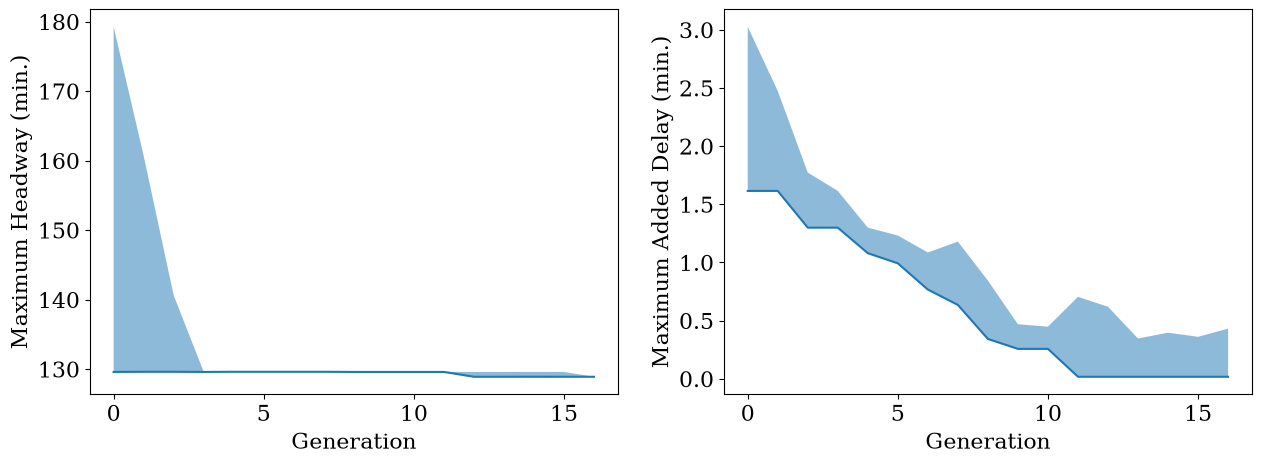

In [138]:

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

max_ht = []
max_hold = []
best_ht = []
best_hold = []
idx = 0
while idx < len(ga_ours.solutions_fitness) // 20:
    best_ht.append(-max(ga_ours.solutions_fitness[idx * 20:idx * 20 + 20], key=lambda x: x[0])[0])
    best_hold.append(-max(ga_ours.solutions_fitness[idx * 20:idx * 20 + 20], key=lambda x: x[1])[1])
    max_ht.append(-sorted(ga_ours.solutions_fitness[idx * 20:idx * 20 + 20], key=lambda x: x[0])[15][0])
    max_hold.append(-sorted(ga_ours.solutions_fitness[idx * 20:idx * 20 + 20], key=lambda x: x[1])[15][1])
    idx += 1
print(best_ht)
ax[0].fill_between([i for i in range(len(best_ht))], best_ht, max_ht, alpha=0.5)
ax[0].plot([i for i in range(len(best_ht))], best_ht)
ax[1].fill_between([i for i in range(len(best_hold))], best_hold, max_hold, alpha=0.5)
ax[1].plot([i for i in range(len(best_hold))], best_hold)
ax[0].set_xlabel("Generation")
ax[1].set_xlabel("Generation")
ax[0].set_ylabel("Maximum Headway (min.)")
ax[1].set_ylabel("Maximum Added Delay (min.)")
#ax[0].set_ylabel(r"$\max\{\overline{HT}^{(i)}\} \forall 0\leq i < N$")
plt.savefig('convergence.png', dpi=300, bbox_inches='tight')
plt.show()

In [144]:
our_solution, our_solution_fitness, our_solution_idx = ga_ours.best_solution()
solution = [None, *our_solution]
our_start_times = [bus * solution[1] for bus in range(N_BUSES)]
OUR_ROUTE = deepcopy(BASE_ROUTE)
param_idx = 2
for stop_idx in range(len(OUR_ROUTE)):
    for idx, ctrl_pt in enumerate(CTRL_PTS):
        if OUR_ROUTE[stop_idx].stop_id == ctrl_pt:
            policy = solution[param_idx]
            arg1 = solution[param_idx + 1]
            arg2 = solution[param_idx + 2]
            param_idx += 3
            if policy == 0:
                pass
            elif policy == 1:
                OUR_ROUTE[stop_idx].policy = InfiniteSchedulePolicy
                OUR_ROUTE[stop_idx].policy_args = {
                    'time_delta': N_BUSES / MAX_TRAVEL * (1 - arg1) + arg1 * N_BUSES / MIN_TRAVEL,
                    'offset': MIN_CTRL[idx] * (1 - arg2) + arg2 * MAX_CTRL[idx],
                }
            elif policy == 2:
                OUR_ROUTE[stop_idx].policy = HeadwayDrivenPolicy
                OUR_ROUTE[stop_idx].policy_args = {
                    'activation_ratio': arg1,
                    'max_holding': arg2 * MAX_HOLD,
                }

#headway_ub, headway_lb = headway_bounds(route_factory(route), start_times, T_MAX)

In [154]:
worst_case = {"no": 0, "liu": 0, "zhao": 0, "ours": 0}
average_case = {"no": [], "liu": [], "zhao": [], "ours": []}
routes = [
    RouteConfig(name=r'\text{No holding}', route=BASE_ROUTE, start_times=zhao_start_times),
    RouteConfig(name=r'\text{Liu et al.}', route=LIU_ROUTE, start_times=liu_start_times),
    RouteConfig(name=r'\text{Zhao et al.}', route=ZHAO_ROUTE, start_times=zhao_start_times),
    RouteConfig(name=r'\text{Ours}', route=OUR_ROUTE, start_times=our_start_times),
]
T_MAX = 60 * 8
results = []
for route in routes:
    print(f'Working on {route.name}...')
    headway_ub, headway_lb = headway_bounds(route_factory(route.route), route.start_times, T_MAX)
    pr_results = simulate(route_factory(route.route), route.start_times, T_MAX)

    
    ub = []
    lb = []
    pr = []
    for stop_idx in range(len(route.route)):
        for idx, ctrl_pt in enumerate(CTRL_PTS):
            if route.route[stop_idx].stop_id == ctrl_pt:
                ub.append(headway_ub[stop_idx])
                lb.append(headway_lb[stop_idx])
                pr.append(pr_results['headway'][stop_idx])
            if "No" in route.name:
                worst_case["no"] = max(worst_case["no"], headway_ub[stop_idx])
                average_case["no"].append(sum(pr_results['headway'][stop_idx])/len(pr_results['headway'][stop_idx]))
            if "Liu" in route.name:
                worst_case["liu"] = max(worst_case["liu"], headway_ub[stop_idx])
                average_case["liu"].append(sum(pr_results['headway'][stop_idx])/len(pr_results['headway'][stop_idx]))
            if "Zhao" in route.name:
                worst_case["zhao"] = max(worst_case["zhao"], max(pr_results['headway'][stop_idx]))
                average_case["zhao"].append(sum(pr_results['headway'][stop_idx])/len(pr_results['headway'][stop_idx]))
            if "Ours" in route.name:
                worst_case["ours"] = max(worst_case["ours"], headway_ub[stop_idx])
                average_case["ours"].append(sum(pr_results['headway'][stop_idx])/len(pr_results['headway'][stop_idx]))
        
    results.append(RouteResults(
        name=route.name,
        route=route.route,
        headway=HeadwayResults(upper_bound=ub, lower_bound=lb, observed=pr),
        travel_time=pr,
    ))

fig = graph_objects.Figure()
whitespace = 0.2
width = (1 - whitespace) / len(results)

for i, result in enumerate(results):
    offset = -0.5 + 0.5 * whitespace + i * width + 0.5 * width

    for stop_idx in range(len(CTRL_PTS)):
        if "Liu" not in result.name:
            fig.add_trace(graph_objects.Bar(
                base=[result.headway.lower_bound[stop_idx]],
                legend='legend1',
                marker={'color': express.colors.qualitative.T10[i]},
                marker_pattern_shape='x',
                name='$' + result.name + r'\textrm{ (Bounds)}' + '$',
                opacity=0.5,
                showlegend=True if stop_idx == 0 else False,
                width=width,
                x=[stop_idx + offset],
                y=[result.headway.upper_bound[stop_idx]],
            ))
        fig.add_trace(graph_objects.Box(
            legend='legend2',
            marker={'color': express.colors.qualitative.T10[i]},
            name='$' + result.name + r'\textrm{ (Sim.)}' + '$',
            opacity=1.0,
            showlegend=True if stop_idx == 0 else False,
            width=width,
            x=[stop_idx + offset] * len(result.headway.observed[stop_idx]),
            y=result.headway.observed[stop_idx],
        ))

fig.update_layout(
    # General style
    font_family='Times New Roman, serif',
    plot_bgcolor='white',

    # Dimensions
    height=360,
    width=750,
    
    # Axes
    xaxis=dict(
        side='top',
        tickmode='array',
        tickvals=[i for i in range(len(CTRL_PTS))],
        title='Control Point',
        title_standoff=0.0,
    ),
    yaxis=dict(
        gridcolor='lightgrey',
        showgrid=True,
        title='Headway Time (min.)',
        title_standoff=0.0,
        zeroline=True,
        zerolinecolor='lightgrey',
    ),

    # Legends
    legend1=dict(
        orientation='v',
        x=0.25,
        xanchor='center',
        y=-0.12 * len(results),
        yanchor='bottom',
    ),
    legend2=dict(
        orientation='v',
        x=0.75,
        xanchor='center',
        y=-0.12 * len(results),
        yanchor='bottom',
    ),
)

fig.show()
fig.write_image(path.join('figures', 'route_optimization.pdf'))

Working on \text{No holding}...
Working on \text{Liu et al.}...


ZeroDivisionError: division by zero

\text{No holding}
\text{No holding}
\text{No holding}
\text{No holding}
\text{No holding}
\text{No holding}
\text{No holding}
\text{No holding}
\text{Liu et al.}
\text{Liu et al.}
\text{Liu et al.}
\text{Liu et al.}
\text{Liu et al.}
\text{Liu et al.}
\text{Liu et al.}
\text{Liu et al.}
\text{Zhao et al.}
\text{Zhao et al.}
\text{Zhao et al.}
\text{Zhao et al.}
\text{Zhao et al.}
\text{Zhao et al.}
\text{Zhao et al.}
\text{Zhao et al.}
\text{Ours}
\text{Ours}
\text{Ours}
\text{Ours}
\text{Ours}
\text{Ours}
\text{Ours}
\text{Ours}


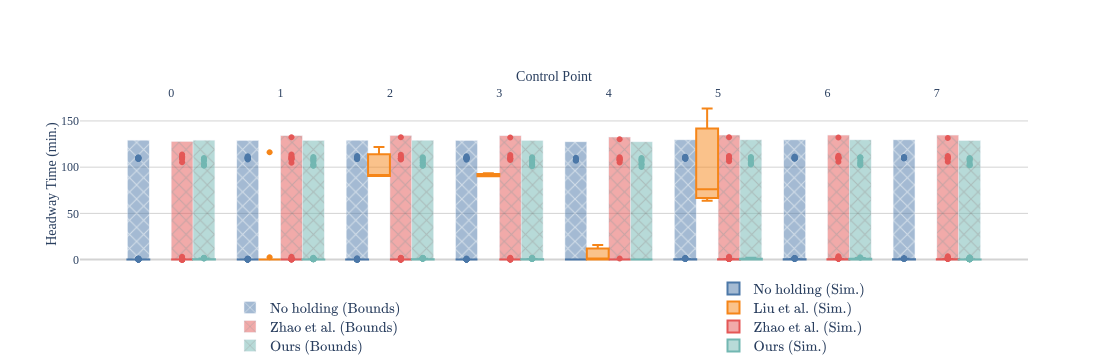

In [151]:
fig = graph_objects.Figure()
whitespace = 0.2
width = (1 - whitespace) / len(results)

for i, result in enumerate(results):
    offset = -0.5 + 0.5 * whitespace + i * width + 0.5 * width

    for stop_idx in range(len(CTRL_PTS)):
        if "Liu" not in result.name:
            fig.add_trace(graph_objects.Bar(
                base=[result.headway.lower_bound[stop_idx]],
                legend='legend1',
                marker={'color': express.colors.qualitative.T10[i]},
                marker_pattern_shape='x',
                name='$' + result.name + r'\textrm{ (Bounds)}' + '$',
                opacity=0.5,
                showlegend=True if stop_idx == 0 else False,
                width=width,
                x=[stop_idx + offset],
                y=[result.headway.upper_bound[stop_idx]],
            ))
        print(result.name)
        fig.add_trace(graph_objects.Box(
            legend='legend2',
            marker={'color': express.colors.qualitative.T10[i]},
            name='$' + result.name + r'\textrm{ (Sim.)}' + '$',
            opacity=1.0,
            showlegend=True if stop_idx == 1 else False,
            width=width,
            x=[stop_idx + offset] * len(result.headway.observed[stop_idx]),
            y=result.headway.observed[stop_idx],
        ))

fig.update_layout(
    # General style
    font_family='Times New Roman, serif',
    plot_bgcolor='white',

    # Dimensions
    height=360,
    width=750,
    
    # Axes
    xaxis=dict(
        side='top',
        tickmode='array',
        tickvals=[i for i in range(len(CTRL_PTS))],
        title='Control Point',
        title_standoff=0.0,
    ),
    yaxis=dict(
        gridcolor='lightgrey',
        showgrid=True,
        title='Headway Time (min.)',
        title_standoff=0.0,
        zeroline=True,
        zerolinecolor='lightgrey',
    ),

    # Legends
    legend1=dict(
        orientation='v',
        x=0.25,
        xanchor='center',
        y=-0.12 * len(results),
        yanchor='bottom',
    ),
    legend2=dict(
        orientation='v',
        x=0.75,
        xanchor='center',
        y=-0.12 * len(results),
        yanchor='bottom',
    ),
)

fig.show()
fig.write_image(path.join('figures', 'route_optimization.pdf'))

In [172]:
#max([max([h for h in s]) if len(s) > 0 else 0 for s in results[2].headway.observed])
sum([sum([h for h in s]) / len(s) if len(s) > 0 else 0 for s in results[2].headway.observed]) / len(results[2].headway.observed)

np.float64(6.456053140844201)

In [159]:
results[0]

RouteResults(name='\\text{Liu et al.}', route=[GtfsStopConfig(tau=(1.0120932682418737, 1.2885101578385987), delta=(0.5439841585571598, 0.5767016820786627), policy=<class 'analysis.policies.BolehPolicy'>, policy_args={}, stop_id='HICHICNN', arrival_rate=0.10971400394477317, mean_dwell=0.5601040789568131, mean_travel=1.1419686759319276, travel_var=1745.8061974879947), GtfsStopConfig(tau=(1.0190866446169367, 1.4308805761472765), delta=(0.20535350237543953, 0.21833922802738287), policy=<class 'analysis.policies.BolehPolicy'>, policy_args={}, stop_id='MTVCURSN', arrival_rate=0.012532051282051282, mean_dwell=0.2117468421992942, mean_travel=1.2075559138994258, travel_var=1972.7268606416258), GtfsStopConfig(tau=(1.510476427675757, 1.9259359697336143), delta=(0.5710900583777472, 0.6076745007494125), policy=<class 'analysis.policies.BolehPolicy'>, policy_args={}, stop_id='MXIMTVIE', arrival_rate=0.11959935897435897, mean_dwell=0.5890983501145207, mean_travel=1.7056027918291745, travel_var=3894.9

In [152]:
worst_case

{'no': np.float64(129.61258203672287),
 'liu': 0,
 'zhao': np.float64(131.6232413204714),
 'ours': np.float64(129.61258203672287)}

In [153]:
average_case

{'no': [np.float64(6.33851319827476)],
 'liu': [np.float64(122.08786134048187)],
 'zhao': [np.float64(6.504115671998425)],
 'ours': [np.float64(6.332572286030677)]}